# E68 · Discrete choice: multinomial logit, mixed logit, willingness to pay and a market simulator

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: Kenneth Train's **stated-preference survey of electricity suppliers** (Huber & Train 2001; `Electricity` in the R package mlogit): 361 US residential customers, each answering up to 12 choice tasks, 4,308 tasks in all, each a choice among 4 hypothetical supplier contracts described by price, contract length, local / well-known company and time-of-day or seasonal rates. A simulated re-run of the survey is used once as a known-truth check (labelled) |
| **You will learn** | The **random-utility** derivation of the logit · the **conditional (multinomial) logit** in PyMC on long data with `(task, alt, attr)` dims · prior predictive checks for choice models (vague priors mean deterministic choices) · **IIA** and why it matters · a **person-level posterior predictive check** that the logit fails badly · the **mixed (random-coefficients) logit**: panel data, an **LKJ** covariance, non-centred person effects · why a **normal price coefficient** breaks **willingness to pay** and how a **lognormal** one fixes it · WTP posteriors: population median vs mean, heterogeneity, individual-level WTP and how little 12 answers tell you · **which unit to leave out** in LOO (task vs person), and why a naive simulated **integrated likelihood** is biased by 100 nats while an importance-sampled one is not · **substitution patterns**: diversion ratios and a red-bus/blue-bus clone, logit vs mixed logit · a **market simulator** for a new contract under parameter and taste uncertainty, and the pricing decision it supports |

## Choosing between things

A lot of applied statistics is about **choices among a small set of alternatives**: which
supplier, which travel mode, which product on a shelf, which contract. The standard tool is the
**discrete choice model** (McFadden, Nobel prize 2000), and its workhorse is the logit. It is
used to price products, forecast demand for things that do not exist yet, value time and
environmental goods, and plan transport networks.

The data here are a classic **stated-preference** (conjoint) experiment run by Kenneth Train
for US electricity suppliers in the late 1990s, when retail electricity markets were being
opened to competition. Each respondent saw up to 12 screens like this one and picked one
supplier:

| | supplier 1 | supplier 2 | supplier 3 | supplier 4 |
|---|---|---|---|---|
| price | 7 c/kWh fixed | 9 c/kWh fixed | time-of-day rates | seasonal rates |
| contract length | 5 years | 1 year | none | 5 years |
| local company | no | yes | no | no |
| well-known company | yes | no | no | yes |

Because the attributes are varied by design, the choices tell us how people trade them off:
**how many cents per kWh is a local supplier worth? How much does a 5-year lock-in cost?** And
because every person answers 12 times, we can see how much people *differ*.

The question we end with is a business one: **a new, unknown, non-local supplier enters this
market. What price and contract should it offer, and whose customers will it take?**

## The plan

1. The data and the random-utility model
2. The conditional logit: priors, fit, a check against maximum likelihood
3. What the logit gets wrong: IIA and a person-level predictive check
4. The mixed logit: random coefficients, LKJ, and the price-coefficient trap
5. Willingness to pay: population, heterogeneity, individuals
6. Model comparison: what does "leave one out" mean for panel choice data?
7. A known-truth check (simulated)
8. Substitution patterns and a market simulator: the pricing decision

In [1]:
import logging
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from scipy import optimize, special, stats

from pymc_challenges import data

RANDOM_SEED = 68
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # several fits: no sampler banner each
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")  # NaN r_hat of constants
warnings.filterwarnings("ignore", message="Estimated shape parameter of Pareto")  # we print k-hat counts
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")


def q(x, probs=(0.05, 0.5, 0.95), axis=None):
    """Posterior quantiles, rounded for printing."""
    return np.round(np.quantile(x, probs, axis=axis), 2)

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


---
# 1 · The data and the random-utility model

## 1.1 · Long format: one row per task and alternative

In [2]:
data.describe("electricity_choice")
raw = data.load("electricity_choice").sort_values(["chid", "alt"]).reset_index(drop=True)
raw.head(8)

electricity_choice: Stated-preference choice experiment: 361 residential customers each made up to 12 choices (4,308 choice tasks; 348 people did all 12) among 4 hypothetical electricity suppliers. Long format, one row per task x alternative (17,232 rows): choice (1 if chosen), id (person), alt (1-4, unlabelled), pf (fixed price, cents/kWh: 7 or 9; 0 when the contract is time-of-day or seasonal), cl (contract length in years: 0, 1 or 5; switching early costs a penalty), loc (local company), wk (well-known company), tod (time-of-day rates: 11c 8am-8pm, 5c otherwise), seas (seasonal rates: 10c summer, 8c winter, 6c spring/fall), chid (choice-task id).
  source: Kenneth Train's stated-preference survey of electricity suppliers (Huber & Train 2001, Marketing Letters 12:259-269; Revelt & Train 2000, UC Berkeley working paper), distributed as `Electricity` in the R package mlogit (GPL >= 2) and, in long format, in the Python package xlogit (GPL-3; the URL). Verified identical, value for valu

,choice,id,alt,pf,cl,loc,wk,tod,seas,chid
0,0,1,1,7,5,0,1,0,0,1
1,0,1,2,9,1,1,0,0,0,1
2,0,1,3,0,0,0,0,0,1,1
3,1,1,4,0,5,0,1,1,0,1
4,0,1,1,7,0,0,1,0,0,2
5,0,1,2,9,5,0,1,0,0,2
6,1,1,3,0,1,1,0,1,0,2
7,0,1,4,0,5,0,0,0,1,2


Choice data come in **long format**: each choice task contributes one row per alternative, and
a 0/1 column marks the chosen one. For modelling we reshape to a 3-D array
$X_{t j a}$ (task $t$, alternative $j$, attribute $a$) and a vector of chosen alternatives
$y_t$.

One recoding matters. A time-of-day (TOD) or seasonal contract has no fixed price (`pf` is 0),
so in the raw coding the TOD dummy absorbs the whole price of a TOD contract and its
coefficient is large (about -5.5, see below). Both variable-rate schedules average **8 c/kWh**
(TOD: 11c for 12 day hours and 5c for 12 night hours; seasonal: 10/8/6 c, averaging 8c if use is
flat over the year), so we give those contracts a price of 8 and keep the dummy. The dummy then
means *the extra dislike of a variable-rate contract beyond its average price*. For fixed
coefficients this is an exact reparameterisation (the likelihood is the same), and it puts every
coefficient on a scale of about 1, which helps priors and interpretation.

In [3]:
T, J = raw.chid.nunique(), 4
ATTR = ["price", "contract", "local", "known", "tod", "seas"]
LABEL = {"price": "price (c/kWh)", "contract": "contract length (yr)", "local": "local company",
         "known": "well-known company", "tod": "time-of-day rates", "seas": "seasonal rates"}


def as_grid(col):
    return raw[col].to_numpy(float).reshape(T, J)


variable = (as_grid("tod") + as_grid("seas")) > 0
X = np.stack([np.where(variable, 8.0, as_grid("pf")), as_grid("cl"), as_grid("loc"),
              as_grid("wk"), as_grid("tod"), as_grid("seas")], axis=-1)   # (task, alt, attr)
y = as_grid("choice").argmax(axis=1)                                     # chosen alternative
people, pid = np.unique(raw["id"].to_numpy().reshape(T, J)[:, 0], return_inverse=True)
N = len(people)
tasks_per = np.bincount(pid)
print(f"{N} people, {T} choice tasks, {J} alternatives each; tasks per person: "
      f"{dict(zip(*np.unique(tasks_per, return_counts=True)))}")
print("attribute levels:", {a: np.unique(X[..., k]).tolist() for k, a in enumerate(ATTR)})
print(f"every task offers at least one variable-rate contract: {variable.any(axis=1).all()}; "
      f"a local supplier is offered in {X[..., 2].max(axis=1).mean():.0%} of tasks")

361 people, 4308 choice tasks, 4 alternatives each; tasks per person: {np.int64(8): np.int64(2), np.int64(9): np.int64(2), np.int64(10): np.int64(1), np.int64(11): np.int64(8), np.int64(12): np.int64(348)}
attribute levels: {'price': [7.0, 8.0, 9.0], 'contract': [0.0, 1.0, 5.0], 'local': [0.0, 1.0], 'known': [0.0, 1.0], 'tod': [0.0, 1.0], 'seas': [0.0, 1.0]}
every task offers at least one variable-rate contract: True; a local supplier is offered in 79% of tasks


## 1.2 · What people chose

Before any model: how often is an alternative chosen, by attribute level? With four
alternatives, 25% is the "no preference" line.

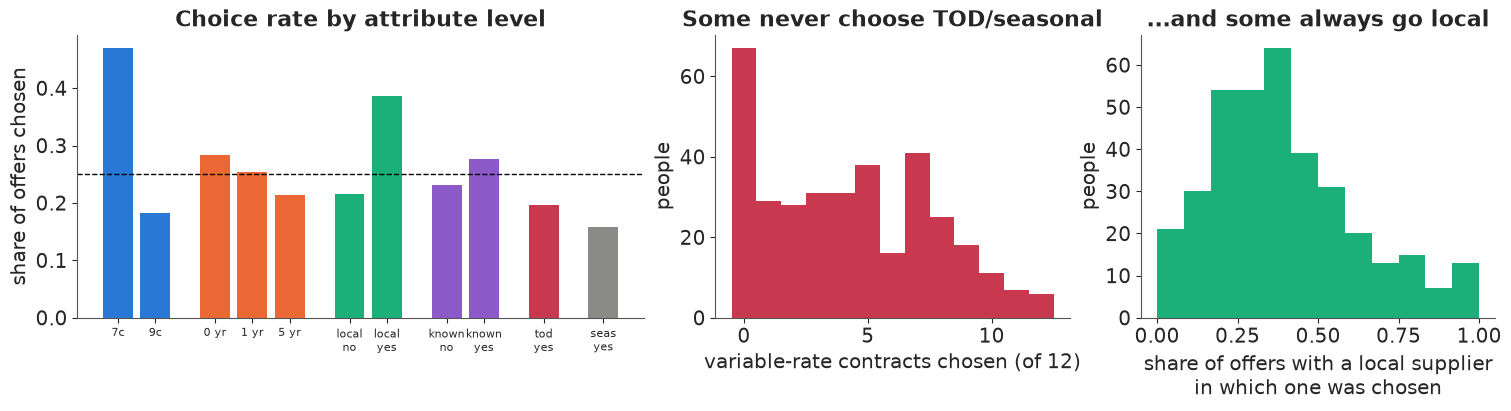

In [4]:
chosen = np.zeros((T, J), bool)
chosen[np.arange(T), y] = True
isvar_chosen = variable[np.arange(T), y]
var_count = np.bincount(pid, weights=isvar_chosen, minlength=N)   # variable-rate picks per person
loc_offered = X[..., 2].max(axis=1) > 0
loc_chosen = X[np.arange(T), y, 2] > 0

fig, axes = plt.subplots(1, 3, figsize=(15, 4), width_ratios=[1.6, 1, 1])
groups = [("price", [7, 8, 9], "{:g}c"), ("contract", [0, 1, 5], "{:g} yr"),
          ("local", [0, 1], None), ("known", [0, 1], None), ("tod", [1], None), ("seas", [1], None)]
xpos, ticks, labels, cols = 0, [], [], []
for k, (a, levels, fmt) in enumerate(groups):
    idx = ATTR.index(a)
    for lev in levels:
        m = X[..., idx] == lev
        if a == "price" and lev == 8:
            m &= ~variable            # no fixed-price contract costs 8c
            if not m.any():
                continue
        rate = chosen[m].mean()
        axes[0].bar(xpos, rate, color=[BLUE, ORANGE, AQUA, PURPLE, RED, GREY][k], width=0.8)
        ticks.append(xpos)
        labels.append(fmt.format(lev) if fmt else f"{a}\n" + ("yes" if lev else "no"))
        xpos += 1
    xpos += 0.6
axes[0].axhline(0.25, color="k", lw=1, ls="--")
axes[0].set_xticks(ticks, labels, fontsize=8)
axes[0].set(ylabel="share of offers chosen", title="Choice rate by attribute level")
axes[1].hist(var_count[tasks_per == 12], bins=np.arange(14) - 0.5, color=RED)
axes[1].set(xlabel="variable-rate contracts chosen (of 12)", ylabel="people",
            title="Some never choose TOD/seasonal")
share_loc = pd.Series(loc_chosen[loc_offered]).groupby(pid[loc_offered]).mean()
axes[2].hist(share_loc, bins=np.linspace(0, 1, 13), color=AQUA)
axes[2].set(xlabel="share of offers with a local supplier\nin which one was chosen", ylabel="people",
            title="...and some always go local");

The marginal patterns are strong and sensible: cheap beats expensive, short contracts beat long
ones, local and well-known companies are popular, variable-rate contracts are unpopular. The
right two panels show something the averages hide: **people are very different**. Among the
348 people who did all 12 tasks, a large group *never* picked a time-of-day or seasonal
contract, although every single task offered one, and at the other end some chose one most of
the time. Local suppliers split people the same way. Keep this picture in mind; the first
model will not be able to reproduce it.

## 1.3 · Random utility

Person $i$ in task $t$ gets utility from alternative $j$

$$U_{itj} = \underbrace{\beta^\top x_{tj}}_{V_{tj}} + \varepsilon_{itj},$$

a systematic part that depends on the attributes and a part the analyst does not see. The
person picks the alternative with the largest utility. If the $\varepsilon$ are independent
**Gumbel** (type-I extreme value) with scale 1, the probability that $j$ has the largest
utility has a closed form (McFadden 1974):

$$P(y_t = j) = \frac{\exp V_{tj}}{\sum_k \exp V_{tk}} = \operatorname{softmax}(V_t)_j .$$

Two consequences follow directly:

* **Only differences in utility matter.** Adding a constant to every $V_{tj}$ changes nothing,
  so there is no intercept (the alternatives here are unlabelled; with labelled alternatives -
  bus, car, train - you would add $J - 1$ alternative-specific constants).
* **Only ratios of coefficients have units.** The standard deviation of $\varepsilon$ is fixed
  at $\pi/\sqrt 6$, so $\beta$ is measured in units of unobserved noise. A coefficient's size is
  not interpretable on its own, but $-\beta_{\text{local}} / \beta_{\text{price}}$ is: it is the
  price increase (c/kWh) that exactly offsets having a local supplier - the **willingness to
  pay** (WTP).

---
# 2 · The conditional logit

## 2.1 · Priors, checked on the choice scale

What does "a vague prior" mean for a choice model? Draw coefficients, compute the choice
probabilities on the real design, and look at **the probability of the most likely
alternative** in each task. Near 0.25 means coin flips; near 1 means deterministic choices.

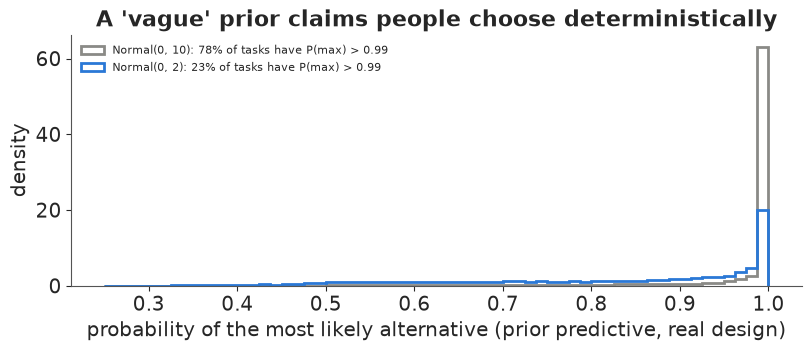

In [5]:
def max_prob(beta):
    """beta: (draws, attr) -> max choice probability per draw and task."""
    return special.softmax(np.einsum("tja,sa->stj", X, beta), axis=2).max(axis=2)


prior_sds = {"Normal(0, 10)": 10.0, "Normal(0, 2)": 2.0}
fig, ax = plt.subplots(figsize=(8, 3.4))
for (name, s), col in zip(prior_sds.items(), [GREY, BLUE]):
    b = np.random.default_rng(1).normal(0, s, size=(300, 6))
    mp = max_prob(b).ravel()
    ax.hist(mp, bins=np.linspace(0.25, 1, 61), density=True, histtype="step", lw=2, color=col,
            label=f"{name}: {np.mean(mp > 0.99):.0%} of tasks have P(max) > 0.99")
ax.set(xlabel="probability of the most likely alternative (prior predictive, real design)",
       ylabel="density", title="A 'vague' prior claims people choose deterministically")
ax.legend(fontsize=8);

Normal(0, 10) on the coefficients is not vague about choices at all: it says that in most tasks
one alternative is chosen with near certainty, because a price coefficient of -10 per cent makes
a 2-cent difference worth 20 units of noise. Normal(0, 2) still allows strong preferences
(tasks with $P > 0.99$ are common) but also plenty of real uncertainty. We use it for the
logit. Attributes are in natural units (cents, years, 0/1), all of order 1-10, so one scale is
acceptable here.

## 2.2 · The model in PyMC

The long data become a `(task, alt, attr)` array; utility is a dot product over `attr`;
`pm.Categorical(logit_p=...)` applies the softmax over `alt`.

In [6]:
coords = {"task": np.arange(T), "alt": [1, 2, 3, 4], "attr": ATTR, "person": people}
with pm.Model(coords=coords) as m_logit:
    Xd = pm.Data("X", X, dims=("task", "alt", "attr"))
    beta = pm.Normal("beta", 0, 2, dims="attr")
    V = (Xd * beta).sum(axis=-1)                        # (task, alt) utilities
    pm.Categorical("y", logit_p=V, observed=y, dims="task")

t0 = time.time()
with m_logit:
    idata_logit = pm.sample(random_seed=RANDOM_SEED)
    pm.compute_log_likelihood(idata_logit)
    pm.sample_posterior_predictive(idata_logit, extend_inferencedata=True, random_seed=RANDOM_SEED)
print(f"sampled in {time.time() - t0:.0f} s, tuning steps "
      f"{idata_logit.posterior.attrs.get('tuning_steps')}, "
      f"divergences {int(idata_logit.sample_stats['diverging'].sum())}")
az.summary(idata_logit, var_names=["beta"], round_to=3)

sampled in 6 s, tuning steps 400, divergences 0


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta[price],-0.626,0.023,-0.663,-0.590,3376.511,3360.940,1.002,0.000,0.000
beta[contract],-0.108,0.008,-0.122,-0.095,3938.191,3403.167,1.002,0.000,0.000
beta[local],1.442,0.050,1.361,1.523,2473.392,2403.430,1.000,0.001,0.001
beta[known],0.996,0.045,0.925,1.068,2420.351,2934.311,1.001,0.001,0.001
beta[tod],-0.461,0.043,-0.529,-0.392,3672.199,3264.066,1.001,0.001,0.001
beta[seas],-0.838,0.046,-0.912,-0.766,3492.804,3209.416,1.002,0.001,0.001


**A check against maximum likelihood.** The logit log-likelihood is concave, so a
6-parameter optimiser finds the MLE immediately. With 4,308 tasks the posterior mean should
sit on it. We also fit the *original* coding (TOD/seasonal price absorbed by the dummies) to
confirm the recoding is only a reparameterisation.

In [7]:
def logit_nll(b, XX):
    v = XX @ b
    return -(v[np.arange(T), y] - special.logsumexp(v, axis=1)).sum()


X_orig = X.copy()
X_orig[..., 0] = as_grid("pf")
mle = optimize.minimize(logit_nll, np.zeros(6), args=(X,), method="BFGS")
mle_orig = optimize.minimize(logit_nll, np.zeros(6), args=(X_orig,), method="BFGS")
post_mean = idata_logit.posterior["beta"].mean(("chain", "draw")).to_numpy()
print(pd.DataFrame({"posterior mean": post_mean, "MLE": mle.x, "MLE, original coding": mle_orig.x},
                   index=ATTR).round(3))
print(f"max log-likelihood: {-mle.fun:.2f} (recoded) vs {-mle_orig.fun:.2f} (original)")
print(f"implied original-coding TOD coefficient: tod + 8 * price = {mle.x[4] + 8 * mle.x[0]:.3f}")

          posterior mean    MLE  MLE, original coding
price             -0.626 -0.625                -0.625
contract          -0.108 -0.108                -0.108
local              1.442  1.442                 1.442
known              0.996  0.996                 0.996
tod               -0.461 -0.461                -5.463
seas              -0.838 -0.838                -5.840
max log-likelihood: -4958.65 (recoded) vs -4958.65 (original)
implied original-coding TOD coefficient: tod + 8 * price = -5.463


Identical log-likelihoods, the TOD and seasonal coefficients map exactly
($-0.461 + 8 \times (-0.625) = -5.463$), and the posterior means agree with the
MLE to the second decimal. With this much data and a concave likelihood the prior hardly
matters for the logit; it will matter more once each person gets their own coefficients.

The logit says: one cent per kWh costs 0.63 utility units; a local supplier is worth
$1.44 / 0.63 \approx 2.3$ c/kWh, a well-known one 1.6 c/kWh, each year of contract -0.17 c/kWh,
and a variable-rate contract is worth less than a fixed contract at the same average price
(0.7 c/kWh less for TOD, 1.3 c/kWh for seasonal). Before believing these numbers, check the
model.

---
# 3 · What the logit gets wrong

## 3.1 · IIA: independence of irrelevant alternatives

The logit implies that the ratio of any two choice probabilities,
$P_j / P_k = \exp(V_j - V_k)$, does not depend on what else is on offer. A consequence is that a
new alternative takes customers from all existing ones **in proportion to their shares**, no
matter how similar it is to each. The textbook case (Debreu 1960's "red bus / blue bus"): if
half of commuters take the car and half the red bus, adding a blue bus identical to the red
one should leave the car's share at 1/2, but the logit predicts 1/3. We will measure this on
the fitted models in section 8.

IIA holds *for one person with fixed tastes*. It fails for a population of people with
different tastes: the new blue bus draws its riders from people who liked buses, not
from car lovers. So the deeper problem with the logit is the one visible in section 1.2: it
gives everyone the same $\beta$.

## 3.2 · A person-level posterior predictive check

The logit reproduces aggregate choice shares well - it is fitted to them. The panel structure
gives a much sharper test: replicate all 12 answers of every person and count, for each person,
how many variable-rate contracts they chose. If everybody shares one $\beta$, the counts are a
sum of independent Bernoulli trials and cannot pile up at 0.

In [8]:
def person_counts(yrep):
    """yrep: (draws, task) replicated choices -> (draws, person) variable-rate picks."""
    picks = variable[np.arange(T)[None, :], yrep]
    return np.stack([np.bincount(pid, weights=p, minlength=N) for p in picks])


def count_hist(counts, full=tasks_per == 12):
    c = counts[..., full] if counts.ndim == 2 else counts[full]
    return np.stack([(c == k).sum(axis=-1) for k in range(13)], axis=-1)


def yrep_draws(idata, n=400):
    yr = idata.posterior_predictive["y"].stack(s=("chain", "draw")).transpose("s", "task")
    return yr.to_numpy()[:: yr.shape[0] // n][:n].astype(int)


obs_hist = count_hist(var_count)
rep_logit = count_hist(person_counts(yrep_draws(idata_logit)))
never_logit = rep_logit[:, 0]
print(f"people (of 348 with 12 tasks) who never chose a variable-rate contract: observed "
      f"{obs_hist[0]}, logit replications 5-50-95%: {q(never_logit)}")

people (of 348 with 12 tasks) who never chose a variable-rate contract: observed 67, logit replications 5-50-95%: [0.  1.5 4. ]


The logit expects one or two such people (at most 4 in 90% of replications); there are 67. This is
not a small misfit: the model cannot represent people who consistently avoid something. The
fix is to let each person have their own coefficients.

---
# 4 · The mixed logit

## 4.1 · Random coefficients

Give person $i$ their own coefficient vector, drawn from a population distribution:

$$\beta_i \sim \mathcal N(\mu, \Sigma), \qquad P(y_{it} = j \mid \beta_i) = \operatorname{softmax}(X_t \beta_i)_j .$$

This is the **mixed logit** (random-parameters logit; Revelt & Train 1998, McFadden & Train
2000). Conditional on $\beta_i$ it is a logit, so IIA holds for each person, but the population
choice probability $\int \operatorname{softmax}(X_t\beta)\,\mathcal N(\beta\mid\mu,\Sigma)\,d\beta$
no longer has IIA. McFadden and Train showed it can approximate any random-utility model. The
panel matters: because the same $\beta_i$ enters all 12 of a person's answers, repeated
choices identify how people differ, not only how they choose on average.

In PyMC, $\Sigma$ gets an **LKJ** prior on its correlation matrix plus half-normal scales, and
the person effects are **non-centred**: $\beta_i = \mu + L z_i$ with $z_i \sim \mathcal N(0, I)$
and $L$ the Cholesky factor. With 12 binary-ish answers per person, each person's data are weak,
which is where non-centred parameterisations work best.

## 4.2 · First attempt: everything normal

The obvious specification makes all six coefficients normal, including price.

In [9]:
def mixed_logit(lognormal_price, X_=X, y_=y, pid_=pid, n_people=N):
    c = coords | {"task": np.arange(len(y_)), "person": np.arange(n_people)}
    with pm.Model(coords=c) as m:
        Xd = pm.Data("X", X_, dims=("task", "alt", "attr"))
        # for the lognormal price, mu[price] is the mean of log(-beta_price)
        mu = pm.Normal("mu", [-0.5 if lognormal_price else 0.0, 0, 0, 0, 0, 0],
                       [1.0 if lognormal_price else 2.0, 2, 2, 2, 2, 2], dims="attr")
        chol, _, _ = pm.LKJCholeskyCov("chol", n=6, eta=2.0, compute_corr=True,
                                       sd_dist=pm.HalfNormal.dist(2.0, shape=6))
        z = pm.Normal("z", 0, 1, dims=("person", "attr"))
        raw_b = mu + z @ chol.T                               # non-centred N(mu, L L^T)
        if lognormal_price:
            raw_b = pt.concatenate([-pt.exp(raw_b[:, :1]), raw_b[:, 1:]], axis=1)
        b = pm.Deterministic("beta", raw_b, dims=("person", "attr"))
        V = (Xd * b[pid_][:, None, :]).sum(axis=-1)
        pm.Categorical("y", logit_p=V, observed=y_, dims="task")
    return m


def fit(model, seed=RANDOM_SEED):
    t0 = time.time()
    with model:
        idata = pm.sample(random_seed=seed)
    print(f"sampled in {time.time() - t0:.0f} s; divergences "
          f"{int(idata.sample_stats['diverging'].sum())}; max tree depth "
          f"{int(idata.sample_stats['depth'].max())}; r_hat max (mu, chol, z) "
          f"{max(float(az.rhat(idata.posterior[v]).max()) for v in ['mu', 'chol', 'z']):.3f}; "
          f"bulk ESS min (mu, chol) "
          f"{min(float(az.ess(idata.posterior[v]).min()) for v in ['mu', 'chol']):.0f}")
    return idata


m_normal = mixed_logit(lognormal_price=False)
idata_normal = fit(m_normal)
az.summary(idata_normal, var_names=["mu", "chol_stds"], round_to=3)

sampled in 18 s; divergences 0; max tree depth 5; r_hat max (mu, chol, z) 1.020; bulk ESS min (mu, chol) 286


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[price],-1.102,0.068,-1.212,-0.996,1455.257,1767.295,1.001,0.002,0.001
mu[contract],-0.264,0.030,-0.313,-0.219,1342.912,2082.021,1.004,0.001,0.000
mu[local],2.639,0.167,2.373,2.911,1097.630,1552.530,1.003,0.005,0.003
mu[known],1.989,0.127,1.783,2.191,1213.221,1851.030,1.002,0.004,0.002
mu[tod],-1.570,0.208,-1.908,-1.246,808.569,1674.331,1.002,0.007,0.004
mu[seas],-1.702,0.163,-1.963,-1.440,1387.857,2019.166,1.002,0.004,0.002
chol_stds[0],0.903,0.072,0.790,1.022,1322.027,1885.265,1.001,0.002,0.001
chol_stds[1],0.454,0.029,0.410,0.503,1264.447,1988.497,1.002,0.001,0.000
chol_stds[2],2.283,0.163,2.030,2.545,1038.852,1595.062,1.000,0.005,0.003
chol_stds[3],1.640,0.131,1.439,1.857,1025.002,1531.845,1.001,0.004,0.002


The sampler is happy. The model, looked at as a description of people, is not: with a mean
price coefficient near -1.1 and a standard deviation near 0.9, the population distribution puts
a sizeable share of people on a **positive** price coefficient - customers who *prefer* to pay
more. That is not plausible for electricity at the same service quality, and it poisons the one
quantity we most want: willingness to pay, which divides by the price coefficient.

In [10]:
tri = np.tril_indices(6)


def hyper(idata, S, seed=0):
    """S posterior draws of mu (S, 6) and the Cholesky factor L (S, 6, 6)."""
    post = az.extract(idata, var_names=["mu", "chol"], num_samples=S, random_seed=seed)
    L = np.zeros((S, 6, 6))
    L[:, tri[0], tri[1]] = post["chol"].transpose("sample", ...).to_numpy()
    return post["mu"].transpose("sample", ...).to_numpy(), L


def population(idata, lognormal_price, S=1000, R=500, seed=1):
    """Coefficients of R simulated people for each of S posterior draws: (S, R, 6)."""
    mu, L = hyper(idata, S, seed)
    B = mu[:, None, :] + np.einsum("sij,srj->sri", L, np.random.default_rng(seed).normal(size=(S, R, 6)))
    if lognormal_price:
        B[..., 0] = -np.exp(B[..., 0])
    return B


B_normal = population(idata_normal, False)
wtp_normal = -B_normal[..., 2] / B_normal[..., 0]                 # WTP for a local supplier
print(f"share of people with a positive price coefficient: {q((B_normal[..., 0] > 0).mean(axis=1))}")
print(f"population WTP for 'local', 1-5-50-95-99% of people: "
      f"{q(wtp_normal, (0.01, 0.05, 0.5, 0.95, 0.99))} c/kWh")
print(f"posterior of the population MEAN WTP (5-50-95%): {q(wtp_normal.mean(axis=1))} c/kWh")

share of people with a positive price coefficient: [0.07 0.11 0.15]
population WTP for 'local', 1-5-50-95-99% of people: [-80.66 -13.73   1.6   18.19  83.4 ] c/kWh
posterior of the population MEAN WTP (5-50-95%): [-13.15   1.99  16.22] c/kWh


About one person in nine is estimated to like higher prices. Their WTP for a local supplier
is *negative* (they would "pay" to avoid a local supplier by being charged more, which they
like), and people with a price coefficient near zero have WTPs of $\pm$80 c/kWh - ten times the
price of electricity. The ratio of two normals has no mean, and it shows: the 90% interval of
the posterior of the population mean WTP runs from roughly -15 to +20 c/kWh, depending on which
draws land near zero. The median is stable, but the model's picture of the population is wrong.

## 4.3 · The fix: a lognormal price coefficient

Write $\beta_{i,\text{price}} = -\exp(\gamma_i)$ with $\gamma_i$ normal (jointly with the other
coefficients). Everybody dislikes paying more, by an amount that varies over people. The prior
on the mean of $\gamma$ is Normal(-0.5, 1): a median price coefficient between about -0.1 and
-4 per cent.

In [11]:
m_lognormal = mixed_logit(lognormal_price=True)
idata_mixed = fit(m_lognormal)
az.summary(idata_mixed, var_names=["mu", "chol_stds"], round_to=3)

sampled in 17 s; divergences 0; max tree depth 5; r_hat max (mu, chol, z) 1.039; bulk ESS min (mu, chol) 177


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu[price],-0.213,0.089,-0.365,-0.074,1118.470,1377.170,1.003,0.003,0.002
mu[contract],-0.273,0.031,-0.324,-0.225,1250.299,1541.247,1.002,0.001,0.000
mu[local],2.602,0.168,2.339,2.869,1001.171,1708.927,1.004,0.005,0.003
mu[known],1.983,0.129,1.781,2.187,1033.532,1772.010,1.005,0.004,0.002
mu[tod],-1.406,0.214,-1.757,-1.062,798.807,1143.631,1.003,0.008,0.004
mu[seas],-1.549,0.173,-1.828,-1.280,911.167,1331.879,1.009,0.006,0.003
chol_stds[0],1.065,0.091,0.924,1.217,718.298,1395.155,1.006,0.003,0.002
chol_stds[1],0.457,0.029,0.412,0.504,1358.792,2013.723,1.001,0.001,0.000
chol_stds[2],2.260,0.162,2.014,2.529,1158.394,1661.444,1.006,0.005,0.003
chol_stds[3],1.615,0.131,1.409,1.825,806.137,1665.168,1.011,0.005,0.002


Clean again (no divergences, r_hat and ESS printed above). The mean coefficients are *larger*
than the logit's (local: about 2.6 against 1.4). That is not a contradiction: in the mixed
logit part of what the logit called noise is now explained by taste differences, the remaining
Gumbel noise is smaller, and since $\beta$ is measured in units of that noise, every
coefficient grows. **Ratios** are comparable across the two models; raw coefficients are not.

Is the person-level misfit fixed? Replicate every person's 12 answers from the mixed logit.

never chose variable rate: observed 67; logit [0.  1.5 4. ]; mixed logit [49. 58. 66.]


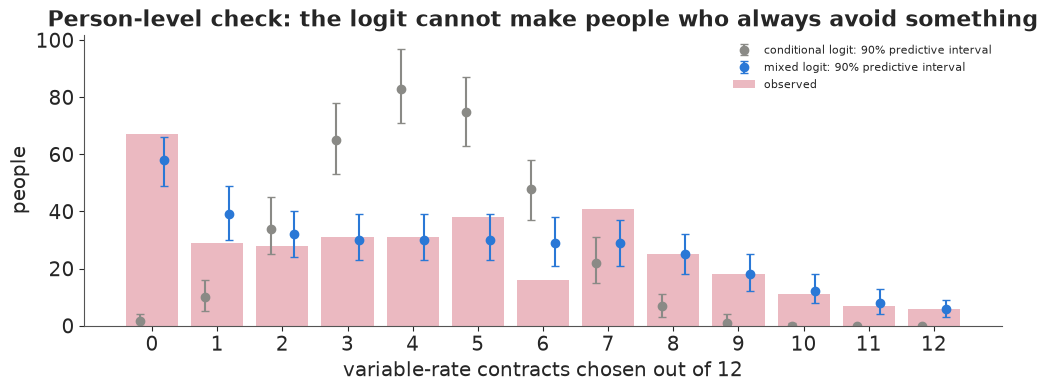

In [12]:
with m_lognormal:
    pm.sample_posterior_predictive(idata_mixed, extend_inferencedata=True, random_seed=RANDOM_SEED)
rep_mixed = count_hist(person_counts(yrep_draws(idata_mixed)))
print(f"never chose variable rate: observed {obs_hist[0]}; logit {q(rep_logit[:, 0])}; "
      f"mixed logit {q(rep_mixed[:, 0])}")

fig, ax = plt.subplots(figsize=(10, 3.8))
k = np.arange(13)
for rep, col, name, dx in [(rep_logit, GREY, "conditional logit", -0.18), (rep_mixed, BLUE, "mixed logit", 0.18)]:
    lo, med, hi = np.quantile(rep, [0.05, 0.5, 0.95], axis=0)
    ax.errorbar(k + dx, med, yerr=[med - lo, hi - med], fmt="o", color=col, capsize=3,
                label=f"{name}: 90% predictive interval")
ax.bar(k, obs_hist, color=RED, alpha=0.35, width=0.8, label="observed")
ax.set(xlabel="variable-rate contracts chosen out of 12", ylabel="people", xticks=k,
       title="Person-level check: the logit cannot make people who always avoid something")
ax.legend(fontsize=8);

The mixed logit reproduces the shape of the distribution: the pile at zero, the long flat
middle and the few people who choose variable rates in 10-12 of their tasks. The observed 67
"never" people sit at the upper edge of its 90% interval (printed above), so the model still slightly
underpredicts complete avoidance - a hint that some people may simply never consider these
contracts (a mass point, or a non-compensatory screening rule) rather than dislike them by a
normally distributed amount. That is a refinement; the logit's failure was of a different
order.

---
# 5 · Willingness to pay

## 5.1 · Population WTP: medians, means and tails

In [13]:
B_mixed = population(idata_mixed, True)
bl = az.extract(idata_logit, var_names=["beta"]).to_numpy()          # (attr, sample)
rows = []
for kk, a in enumerate(ATTR[1:], start=1):
    w_logit = -bl[kk] / bl[0]
    w_mixed = -B_mixed[..., kk] / B_mixed[..., 0]
    rows.append({"attribute": LABEL[a],
                 "logit WTP": f"{np.median(w_logit):.2f} [{q(w_logit)[0]:.2f}, {q(w_logit)[2]:.2f}]",
                 "mixed: median person": "{:.2f} [{:.2f}, {:.2f}]".format(*q(np.median(w_mixed, axis=1))[[1, 0, 2]]),
                 "mixed: 10-90% of people": "{:.1f} to {:.1f}".format(*np.median(np.quantile(w_mixed, [0.1, 0.9], axis=1), axis=1)),
                 "mixed: population mean": "{:.2f} [{:.2f}, {:.2f}]".format(*q(w_mixed.mean(axis=1))[[1, 0, 2]])})
wtp_table = pd.DataFrame(rows).set_index("attribute")
print("WTP in c/kWh: posterior median [90% interval]")
wtp_table

WTP in c/kWh: posterior median [90% interval]

,logit WTP,mixed: median person,mixed: 10-90% of people,mixed: population mean
attribute,,,,
contract length (yr),"-0.17 [-0.20, -0.15]","-0.22 [-0.29, -0.16]",-1.6 to 0.5,"-0.40 [-0.65, -0.19]"
local company,"2.30 [2.15, 2.48]","2.82 [2.20, 3.60]",-0.1 to 19.3,"7.92 [5.74, 11.44]"
well-known company,"1.59 [1.46, 1.73]","2.09 [1.65, 2.64]",-0.0 to 12.9,"5.27 [3.94, 7.52]"
time-of-day rates,"-0.74 [-0.87, -0.61]","-1.15 [-1.73, -0.74]",-12.8 to 3.4,"-3.59 [-6.11, -1.89]"
seasonal rates,"-1.34 [-1.50, -1.19]","-1.39 [-1.88, -1.00]",-11.5 to 1.6,"-3.89 [-6.03, -2.53]"


Read the table row by row for "local company":

* the **logit** gives one number (about 2.3 c/kWh) with a tight interval, because it assumes
  everyone is the same;
* the **median person** in the mixed logit would pay somewhat more (about 2.8 c/kWh; interval in
  the table);
* but **people differ enormously**: the middle 80% range from about 0 to 20 c/kWh;
* and the **population mean** is much larger than the median (around 8 c/kWh) because a
  lognormal price coefficient has a left tail near zero: a few very price-insensitive people
  have huge WTPs. Unlike the normal model, this mean exists and has a finite posterior, but it
  is driven by the tail of an assumed distribution.

Which one to report depends on the question: the median describes a typical customer; the mean
is what matters for aggregate welfare or revenue if everyone could be charged their own WTP. For
pricing (section 8) we simulate the whole distribution instead of summarising it.

The contract-length row confirms that a long lock-in costs roughly 0.2 c/kWh per year for the
median person, and the variable-rate rows that TOD and seasonal contracts must be about 1.2 and
1.4 c/kWh cheaper on average than a fixed one to be equally attractive to the median person.

**Published analyses.** Train's own mixed-logit analyses of these data (Huber & Train 2001;
the mixed-logit chapters of Train's *Discrete Choice Methods with Simulation*) use the raw
coding and different distributional choices for price. We have not reproduced their tables and
make no numeric comparison with them here; the verifiable anchor is section 2's maximum-likelihood
conditional logit, which any logit software (e.g. `mlogit` in R) reproduces on these data.

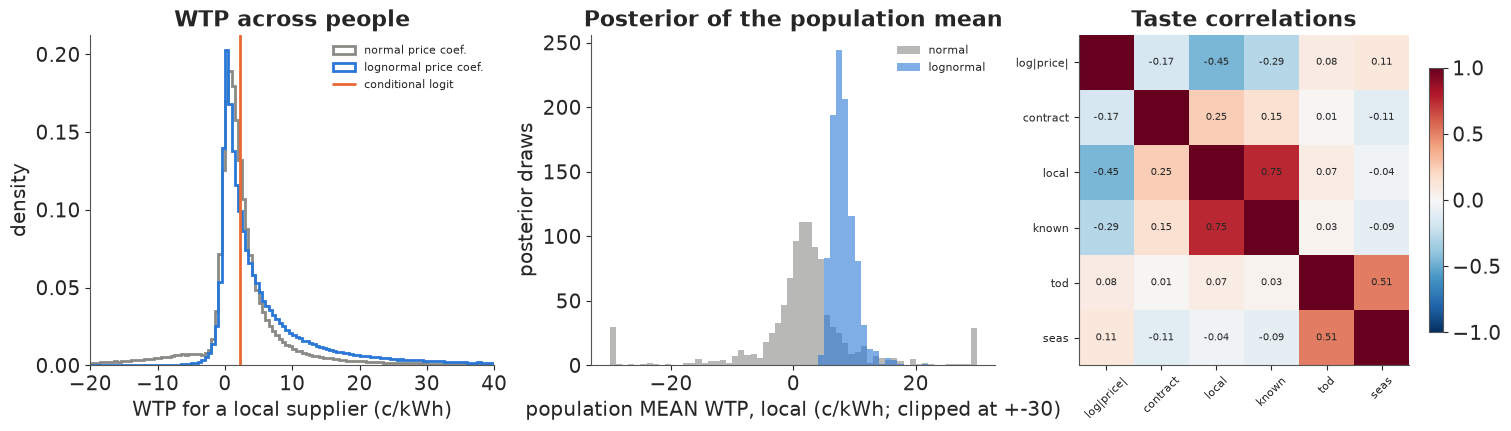

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
bins = np.linspace(-20, 40, 121)
axes[0].hist(wtp_normal.ravel(), bins=bins, density=True, histtype="step", lw=2, color=GREY,
             label="normal price coef.")
axes[0].hist((-B_mixed[..., 2] / B_mixed[..., 0]).ravel(), bins=bins, density=True, histtype="step",
             lw=2, color=BLUE, label="lognormal price coef.")
axes[0].axvline(np.median(-bl[2] / bl[0]), color=ORANGE, lw=2, label="conditional logit")
axes[0].set(xlabel="WTP for a local supplier (c/kWh)", ylabel="density", xlim=(-20, 40),
            title="WTP across people")
axes[0].legend(fontsize=8)
for vals, col, name in [(wtp_normal.mean(axis=1), GREY, "normal"),
                        ((-B_mixed[..., 2] / B_mixed[..., 0]).mean(axis=1), BLUE, "lognormal")]:
    axes[1].hist(np.clip(vals, -30, 30), bins=np.linspace(-30, 30, 61), color=col, alpha=0.6, label=name)
axes[1].set(xlabel="population MEAN WTP, local (c/kWh; clipped at +-30)", ylabel="posterior draws",
            title="Posterior of the population mean")
axes[1].legend(fontsize=8)
# correlation of the random coefficients (lognormal model: first row is log|price coef|)
mu_s, L_s = hyper(idata_mixed, 1000)
cov = np.einsum("sij,skj->sik", L_s, L_s)
sd_s = np.sqrt(np.einsum("sii->si", cov))
corr = (cov / sd_s[:, :, None] / sd_s[:, None, :]).mean(axis=0)
im = axes[2].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
names = ["log|price|", "contract", "local", "known", "tod", "seas"]
axes[2].set_xticks(range(6), names, rotation=45, fontsize=8)
axes[2].set_yticks(range(6), names, fontsize=8)
for i in range(6):
    for j in range(6):
        if i != j:
            axes[2].text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=7)
axes[2].set_title("Taste correlations")
fig.colorbar(im, ax=axes[2], shrink=0.8);

The correlation matrix is worth reading. Liking **local** and liking **well-known** suppliers
go together strongly (a taste for familiar, trustworthy suppliers). The TOD and seasonal
dislikes are positively correlated (a general attitude to variable rates). The price
sensitivity (its log magnitude) correlates *negatively* with the local preference: people who
care a lot about local suppliers tend to care less about price, which is precisely what makes
the WTP distribution so right-skewed. An independent (diagonal) $\Sigma$ would miss all of this.

## 5.2 · Individual WTP: how much do 12 answers tell you?

The model also gives each respondent's own posterior. Marketers like "individual-level
part-worths"; here is what they look like for the local-supplier WTP.

median width of a person's 90% interval: 11.2 c/kWh; persons whose interval excludes 0: 63%


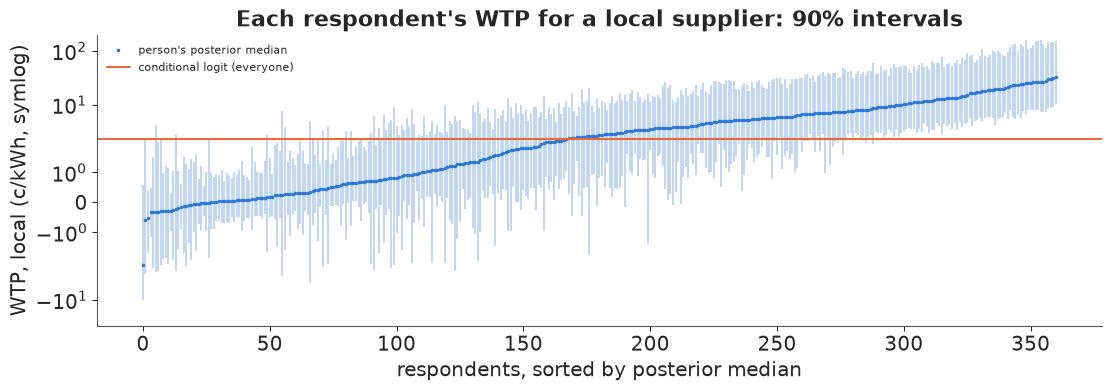

In [15]:
b_ind = az.extract(idata_mixed, var_names=["beta"], num_samples=400).transpose("sample", ...).to_numpy()
w_ind = -b_ind[..., 2] / b_ind[..., 0]                               # (draw, person)
med_i = np.median(w_ind, axis=0)
lo_i, hi_i = np.quantile(w_ind, [0.05, 0.95], axis=0)
order = np.argsort(med_i)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.vlines(np.arange(N), lo_i[order], hi_i[order], color=BLUE, alpha=0.35, lw=1.2)
ax.plot(np.arange(N), med_i[order], ".", color=BLUE, ms=3, label="person's posterior median")
ax.axhline(np.median(-bl[2] / bl[0]), color=ORANGE, lw=1.5, label="conditional logit (everyone)")
ax.set(yscale="symlog", ylim=(-30, 200), xlabel="respondents, sorted by posterior median",
       ylabel="WTP, local (c/kWh, symlog)", title="Each respondent's WTP for a local supplier: 90% intervals")
ax.legend(fontsize=8)
width = hi_i - lo_i
print(f"median width of a person's 90% interval: {np.median(width):.1f} c/kWh; "
      f"persons whose interval excludes 0: {np.mean(lo_i > 0):.0%}")

Individual intervals are wide (the typical 90% interval spans about 11 c/kWh) because 12
answers carry little information about six coefficients; only about two thirds of the
intervals exclude zero. The ordering is informative - some
people are clearly indifferent to local suppliers, others clearly devoted - but a single
person's WTP is not a precise number. Use individual posteriors for segmentation or targeting
with their uncertainty, never as point estimates.

---
# 6 · Model comparison: what does "leave one out" mean here?

## 6.1 · Leave out a choice task

`az.loo` on the per-task log-likelihood answers: *how well does the model predict a new
answer from a person it has already seen 11 times?*

In [16]:
for idt, m in [(idata_normal, m_normal), (idata_mixed, m_lognormal)]:
    with m:
        pm.compute_log_likelihood(idt)
loo_task = {name: az.loo(idt, pointwise=True) for name, idt in
            [("conditional logit", idata_logit), ("mixed, normal price", idata_normal),
             ("mixed, lognormal price", idata_mixed)]}
for name, lo in loo_task.items():
    print(f"{name:>24}: elpd_loo {lo.elpd:8.1f} (se {lo.se:4.1f}), "
          f"tasks with Pareto k > 0.7: {int((lo.pareto_k > 0.7).sum())}")
az.compare(loo_task, round_to=1)

       conditional logit: elpd_loo  -4964.6 (se 41.1), tasks with Pareto k > 0.7: 0
     mixed, normal price: elpd_loo  -3080.6 (se 55.2), tasks with Pareto k > 0.7: 80
  mixed, lognormal price: elpd_loo  -3060.6 (se 54.8), tasks with Pareto k > 0.7: 110


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
"mixed, lognormal price",0,0.0,0.0,NaN,,110 k̂ > 0.70,1068.8,-3060.6,54.8,0.9
"mixed, normal price",1,-20.0,6.7,1.0,,80 k̂ > 0.70,1103.0,-3080.6,55.2,0.1
conditional logit,2,-1904.0,51.3,1.0,,,6.0,-4964.6,41.1,0.0


The mixed logits win by about 1,900 nats - an enormous margin, because knowing a person's
other answers makes their next answer much more predictable - and the lognormal price is ahead
of the normal one by 15-20 nats (about 3 standard errors; the exact value moves a little from
run to run). But two warnings. First, roughly 60-110 tasks have Pareto $k > 0.7$: removing one
of only 12 answers can move that person's posterior a lot, and PSIS cannot always approximate
it. Second, and more important, this is
the right question only if you want to predict *known* customers. A market simulator is used
for **new** people.

## 6.2 · Leave out a person

To predict a new person we must leave out all 12 of their answers, and the prediction must
integrate over the unknown $\beta_i$:

$$p(y_i \mid \mu, \Sigma) = \int \prod_{t} P(y_{it} \mid \beta)\; \mathcal N(\beta \mid \mu, \Sigma)\, d\beta .$$

Summing the conditional log-likelihood (given the sampled $\beta_i$) by person does not work:
$\beta_i$ is informed *only* by person $i$, so leaving them out changes it completely (you will
see $k > 0.7$ for nearly everyone). The integrated likelihood above, used as the pointwise
log-likelihood of each person, is the right object (Vehtari et al. 2016 on LOO for latent
variable models). It is a 6-dimensional integral per person and posterior draw.

**The obvious Monte Carlo estimate is badly biased.** Draw $R$ coefficient vectors from
$\mathcal N(\mu, \Sigma)$ and average the probabilities of the 12 answers. The product of 12
probabilities is tiny for most draws and large for a few, so the average is dominated by rare
draws; with too few, $\log$ of the average is biased *down* (Jensen). **Importance sampling**
from each person's own posterior (a multivariate-t fitted to their posterior draws of $\beta_i$)
puts the draws where the integrand is.

In [17]:
XF = X.reshape(T * J, 6)
M = np.zeros((T, N))
M[np.arange(T), pid] = 1.0                                  # task -> person summation matrix
tasks_of = [np.flatnonzero(pid == i) for i in range(N)]


def naive_person_ll(idata, lognormal_price, S=200, R=200, seed=0):
    """log p(y_i | mu, Sigma) by plain Monte Carlo from the population distribution: (S, N)."""
    mu, L = hyper(idata, S, seed)
    Z = np.random.default_rng(seed).normal(size=(R, 6))
    out = np.empty((S, N))
    for s in range(S):
        B = mu[s] + Z @ L[s].T
        if lognormal_price:
            B[:, 0] = -np.exp(B[:, 0])
        V = (XF @ B.T).reshape(T, J, R)
        lp = V[np.arange(T), y] - special.logsumexp(V, axis=1)          # (task, R)
        out[s] = special.logsumexp(M.T @ lp, axis=1) - np.log(R)
    return out


def is_person_ll(idata, lognormal_price, S=400, R=1000, seed=0, df=5, inflate=1.3):
    """Same integral, importance-sampled from a t fitted to each person's posterior."""
    r = np.random.default_rng(seed)
    b = idata.posterior["beta"].stack(s=("chain", "draw")).transpose("person", "s", "attr").to_numpy().copy()
    if lognormal_price:
        b[..., 0] = np.log(-b[..., 0])                           # back to the normal scale
    m = b.mean(axis=1)
    C = np.einsum("psa,psb->pab", b - m[:, None], b - m[:, None]) / b.shape[1] * inflate**2
    Lq = np.linalg.cholesky(C + 1e-9 * np.eye(6))
    g = r.chisquare(df, (N, R, 1)) / df
    draws = m[:, None] + np.einsum("pab,prb->pra", Lq, r.standard_normal((N, R, 6))) / np.sqrt(g)
    logq = np.array([stats.multivariate_t(m[i], C[i], df=df).logpdf(draws[i]) for i in range(N)])
    loglik = np.empty((N, R))
    for i in range(N):
        B = draws[i].copy()
        if lognormal_price:
            B[:, 0] = -np.exp(B[:, 0])
        V = np.einsum("tja,ra->rtj", X[tasks_of[i]], B)
        loglik[i] = (V[:, np.arange(len(tasks_of[i])), y[tasks_of[i]]]
                     - special.logsumexp(V, axis=2)).sum(axis=1)
    mu, L = hyper(idata, S, seed)
    out = np.empty((S, N))
    for s in range(S):                                           # population density of each draw
        zz = np.linalg.solve(L[s], (draws - mu[s]).reshape(-1, 6).T).T.reshape(N, R, 6)
        logp = -0.5 * (zz**2).sum(-1) - np.log(np.diag(L[s])).sum() - 3 * np.log(2 * np.pi)
        out[s] = special.logsumexp(loglik - logq + logp, axis=1) - np.log(R)
    return out


def loo_from(ll):
    dt = xr.DataTree.from_dict({
        "posterior": xr.Dataset({"dummy": (("chain", "draw"), np.zeros((1, ll.shape[0])))}),
        "log_likelihood": xr.Dataset({"y": (("chain", "draw", "person"), ll[None])})})
    return az.loo(dt, pointwise=True)


t0 = time.time()
ll_naive = naive_person_ll(idata_mixed, True)
ll_is = is_person_ll(idata_mixed, True)
ll_is2 = is_person_ll(idata_mixed, True, R=200, seed=1)
print(f"sum over people of E[log p(y_i | mu, Sigma)]: naive MC (R=200) {ll_naive.mean(0).sum():.0f}, "
      f"importance sampling R=1000 {ll_is.mean(0).sum():.0f}, R=200 (other seed) "
      f"{ll_is2.mean(0).sum():.0f}   [{time.time() - t0:.0f} s]")

sum over people of E[log p(y_i | mu, Sigma)]: naive MC (R=200) -3773, importance sampling R=1000 -3673, R=200 (other seed) -3673   [17 s]


The naive estimate is about 100 nats lower than the importance-sampled one, and the
importance-sampled one is stable to a nat between 200 and 1,000 draws and across seeds. (In a
prototype, the naive estimate climbed from about -3,773 to -3,685 as $R$ went from 200 to 2,000:
still not converged, and 5 times the cost.) A model comparison built on the naive estimate
would penalise whichever model has more heterogeneity - exactly the wrong direction.

Now the person-level comparison. For the logit there is nothing to integrate, so summing its
task log-likelihood by person is exact.

In [18]:
ll_logit_person = (idata_logit.log_likelihood["y"].stack(s=("chain", "draw")).transpose("s", "task")
                   .to_numpy() @ M)
loo_person = {"conditional logit": loo_from(ll_logit_person[:: ll_logit_person.shape[0] // 400]),
              "mixed, normal price": loo_from(is_person_ll(idata_normal, False)),
              "mixed, lognormal price": loo_from(ll_is)}
for name, lo in loo_person.items():
    print(f"{name:>24}: elpd_loo {lo.elpd:8.1f} (se {lo.se:4.1f}), max Pareto k {float(lo.pareto_k.max()):.2f}")
for lo in list(loo_task.values()) + list(loo_person.values()):
    lo.log_weights = None                      # the big importance-weight matrices (memory)
for idt in (idata_logit, idata_normal, idata_mixed):
    del idt["log_likelihood"]
az.compare(loo_person, round_to=1)

       conditional logit: elpd_loo  -4970.4 (se 57.8), max Pareto k 0.31
     mixed, normal price: elpd_loo  -3694.5 (se 73.1), max Pareto k 0.38
  mixed, lognormal price: elpd_loo  -3686.5 (se 73.1), max Pareto k 0.40


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
"mixed, lognormal price",0,0.0,0.0,NaN,,,27.1,-3686.5,73.1,0.7
"mixed, normal price",1,-8.0,5.5,0.9,,,27.1,-3694.5,73.1,0.2
conditional logit,2,-1283.9,66.2,1.0,,,17.3,-4970.4,57.8,0.0


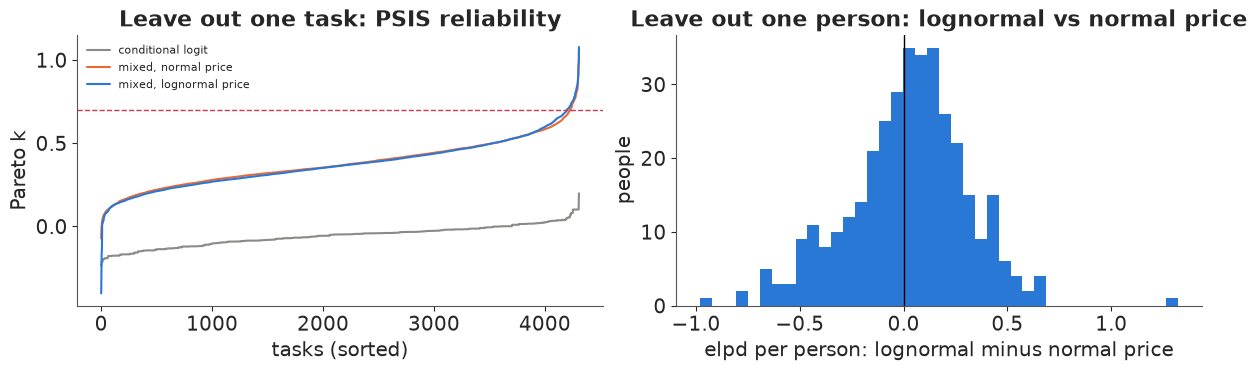

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for (name, lo), col in zip(loo_task.items(), [GREY, ORANGE, BLUE]):
    axes[0].plot(np.sort(np.asarray(lo.pareto_k).ravel()), color=col, label=name)
axes[0].axhline(0.7, color=RED, ls="--", lw=1)
axes[0].set(xlabel="tasks (sorted)", ylabel="Pareto k", title="Leave out one task: PSIS reliability")
axes[0].legend(fontsize=8)
d_person = loo_person["mixed, lognormal price"].elpd_i - loo_person["mixed, normal price"].elpd_i
axes[1].hist(np.asarray(d_person), bins=40, color=BLUE)
axes[1].axvline(0, color="k", lw=1)
axes[1].set(xlabel="elpd per person: lognormal minus normal price", ylabel="people",
            title="Leave out one person: lognormal vs normal price");

Leaving out whole people, the integrated mixed logits still beat the logit by more than 1,200
nats: taste heterogeneity is a real feature of the population, not only of the individuals
already seen. All Pareto $k$ are below 0.5, because a single person moves the population
hyperparameters only slightly. Between the two mixed logits the data barely choose: the
**lognormal price** model is ahead by 7-8 nats with a standard error of about 5.5, and per
person the differences scatter around zero in both directions. So the case for the lognormal
price coefficient is mainly the economic one (section 4.2) - the data do not object to it and
lean slightly in its favour.

The two LOOs answer different questions. Here the ranking is the same, but the size of the gaps
and the reliability diagnostics are not. **Choose the unit you leave out to
match the prediction task**: new answers from known people (task LOO; e.g. recommending a
contract to an existing customer), or new people (person LOO; e.g. market simulation).

---
# 7 · A known-truth check (simulated)

Can 12 answers each from 361 people really identify six means, six scales and fifteen
correlations? Simulate a new survey on the **same design** from a known population (the
posterior mean of the fitted hyperparameters), refit, and compare.

sampled in 16 s; divergences 0; max tree depth 5; r_hat max (mu, chol, z) 1.029; bulk ESS min (mu, chol) 185
90% intervals covering the truth: means 67%, scales 67%, correlations 93%
posterior median / truth: [1.77 1.09 1.15 1.18 1.08 0.95] (means), [1.25 1.07 1.13 1.11 1.05 0.95] (scales)
realised / truth       : [1.43 1.   1.1  1.1  1.1  1.02] (means), [1.04 1.03 1.08 1.07 1.03 1.  ] (scales)


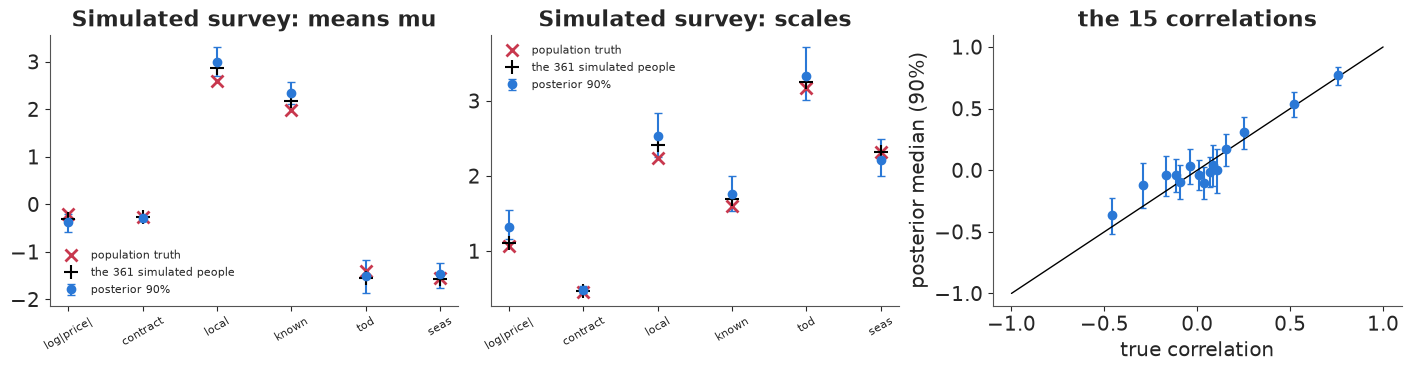

In [20]:
mu_true = idata_mixed.posterior["mu"].mean(("chain", "draw")).to_numpy()
L_true = np.zeros((6, 6))
L_true[tri] = idata_mixed.posterior["chol"].mean(("chain", "draw")).to_numpy()
rs = np.random.default_rng(2068)
B_true = mu_true + rs.normal(size=(N, 6)) @ L_true.T
B_true[:, 0] = -np.exp(B_true[:, 0])
p_sim = special.softmax(np.einsum("tja,ta->tj", X, B_true[pid]), axis=1)
y_sim = (p_sim.cumsum(axis=1) > rs.uniform(size=(T, 1))).argmax(axis=1)
idata_sim = fit(mixed_logit(True, y_=y_sim))
sd_true = np.sqrt((L_true**2).sum(axis=1))
raw_true = B_true.copy()
raw_true[:, 0] = np.log(-raw_true[:, 0])                  # the 361 simulated people, normal scale
mean_realised, sd_realised = raw_true.mean(axis=0), raw_true.std(axis=0)
cov_true = L_true @ L_true.T
corr_true = cov_true / np.outer(sd_true, sd_true)
mu_sim, L_sim = hyper(idata_sim, 1000)
cov_sim = np.einsum("sij,skj->sik", L_sim, L_sim)
sd_sim = np.sqrt(np.einsum("sii->si", cov_sim))
corr_sim = cov_sim / sd_sim[:, :, None] / sd_sim[:, None, :]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for ax, draws, truth, realised, title in [(axes[0], mu_sim, mu_true, mean_realised, "means mu"),
                                          (axes[1], sd_sim, sd_true, sd_realised, "scales")]:
    lo, med, hi = np.quantile(draws, [0.05, 0.5, 0.95], axis=0)
    ax.errorbar(range(6), med, yerr=[med - lo, hi - med], fmt="o", color=BLUE, capsize=3, label="posterior 90%")
    ax.plot(range(6), truth, "x", color=RED, ms=9, mew=2, label="population truth")
    ax.plot(range(6), realised, "+", color="k", ms=10, mew=1.5, label="the 361 simulated people")
    ax.set_xticks(range(6), names, rotation=30, fontsize=8)
    ax.set_title(f"Simulated survey: {title}")
    ax.legend(fontsize=8)
iu = np.triu_indices(6, 1)
lo, med, hi = np.quantile(corr_sim[:, iu[0], iu[1]], [0.05, 0.5, 0.95], axis=0)
axes[2].errorbar(corr_true[iu], med, yerr=[med - lo, hi - med], fmt="o", color=BLUE, capsize=2)
axes[2].plot([-1, 1], [-1, 1], color="k", lw=1)
axes[2].set(xlabel="true correlation", ylabel="posterior median (90%)", title="the 15 correlations")
covered = np.mean((np.quantile(corr_sim[:, iu[0], iu[1]], 0.05, axis=0) <= corr_true[iu])
                  & (corr_true[iu] <= np.quantile(corr_sim[:, iu[0], iu[1]], 0.95, axis=0)))
print(f"90% intervals covering the truth: means {np.mean((q(mu_sim, (0.05,), axis=0)[0] <= mu_true) & (mu_true <= q(mu_sim, (0.95,), axis=0)[0])):.0%}, "
      f"scales {np.mean((np.quantile(sd_sim, 0.05, axis=0) <= sd_true) & (sd_true <= np.quantile(sd_sim, 0.95, axis=0))):.0%}, "
      f"correlations {covered:.0%}")
print("posterior median / truth:", np.round(np.median(mu_sim, axis=0) / mu_true, 2), "(means),",
      np.round(np.median(sd_sim, axis=0) / sd_true, 2), "(scales)")
print("realised / truth       :", np.round(mean_realised / mu_true, 2), "(means),",
      np.round(sd_realised / sd_true, 2), "(scales)")
del idata_sim, cov_sim, corr_sim

Two of the six means (local, well-known) and two of the six scales (log|price|, local) miss the
population truth (red crosses) with their 90% intervals, all on the high side. For the two means
the black crosses explain most of it: the 361 simulated people happen to like local and
well-known suppliers about 10% more than the population they were drawn from, and the posterior
follows the people it has seen. The spread of log|price| is overestimated by about 25% even
relative to the simulated people, so price heterogeneity is the least well pinned-down part of
the model. One simulated survey cannot tell a small systematic bias from bad luck; that needs
many replications (e.g. simulation-based calibration). The correlations are recovered well: the three large ones we interpreted (local with
well-known, TOD with seasonal, price with local) are clearly identified, and the small ones
shrink towards zero as the LKJ(2) prior intends. No parameter is unidentified.

---
# 8 · Substitution patterns and a market simulator

## 8.1 · A market

To use the model we need a market. We define one (an **assumption**, not data): three existing
offers, all within the price range of the survey (7-9 c/kWh).

| competitor | price | contract | local | well-known | rates |
|---|---|---|---|---|---|
| Incumbent | 9c | none | yes | yes | fixed |
| National discounter | 7c | 5 years | no | yes | fixed |
| Incumbent TOD plan | 8c average | none | yes | yes | time-of-day |

A **new entrant**, neither local nor known, considers a fixed-price offer. Market shares come
from the model in two ways: the logit uses one $\beta$ per posterior draw; the mixed logit
simulates 1,000 customers from $\mathcal N(\mu, \Sigma)$ for each posterior draw and averages
their choice probabilities, so both **parameter uncertainty** and **taste heterogeneity** are in
the shares. Like the survey, the market has no "stay with my current supplier" option: shares
are among customers who pick one of these offers.

In [21]:
competitors = pd.DataFrame(
    [[9, 0, 1, 1, 0, 0], [7, 5, 0, 1, 0, 0], [8, 0, 1, 1, 1, 0]], columns=ATTR,
    index=["Incumbent", "National discounter", "Incumbent TOD"], dtype=float)
C = competitors.to_numpy()
S_MKT, R_MKT = 300, 1000
beta_logit_mkt = bl[:, np.random.default_rng(3).choice(bl.shape[1], S_MKT, replace=False)].T
B_mkt = population(idata_mixed, True, S=S_MKT, R=R_MKT, seed=3)          # (S, R, 6)


def shares(profiles, model):
    """profiles (K, 6) -> posterior draws of market shares (S, K)."""
    if model == "logit":
        return special.softmax(beta_logit_mkt @ profiles.T, axis=1)
    return special.softmax(np.einsum("sra,ka->srk", B_mkt, profiles), axis=2).mean(axis=1)


base = {m: shares(C, m) for m in ["logit", "mixed"]}
print(pd.DataFrame({m: [f"{v:.1%}" for v in base[m].mean(axis=0)] for m in base}, index=competitors.index))

                     logit  mixed
Incumbent            37.4%  38.7%
National discounter  18.1%  24.6%
Incumbent TOD        44.5%  36.7%


## 8.2 · Where does the entrant's share come from?

Add the entrant at 8c with a 1-year contract and compute **diversion ratios**: of every
customer the entrant wins, what fraction came from each competitor? Then the red-bus test: add
an exact **clone** of the national discounter.

In [22]:
entrant = np.array([8, 1, 0, 0, 0, 0], float)
rows = []
for m in ["logit", "mixed"]:
    s1 = shares(np.vstack([C, entrant]), m)
    div = (base[m] - s1[:, :3]) / s1[:, [3]]
    s_clone = shares(np.vstack([C, C[1]]), m)
    rows.append({"model": m, "entrant share": s1[:, 3].mean(),
                 **{f"from {c}": v for c, v in zip(competitors.index, div.mean(axis=0))},
                 "discounter alone": base[m][:, 1].mean(),
                 "discounter + clone": (s_clone[:, 1] + s_clone[:, 3]).mean()})
subst = pd.DataFrame(rows).set_index("model")
subst.round(3)

,entrant share,from Incumbent,from National discounter,from Incumbent TOD,discounter alone,discounter + clone
model,,,,,,
logit,0.052,0.374,0.181,0.445,0.181,0.306
mixed,0.063,0.343,0.481,0.177,0.246,0.296


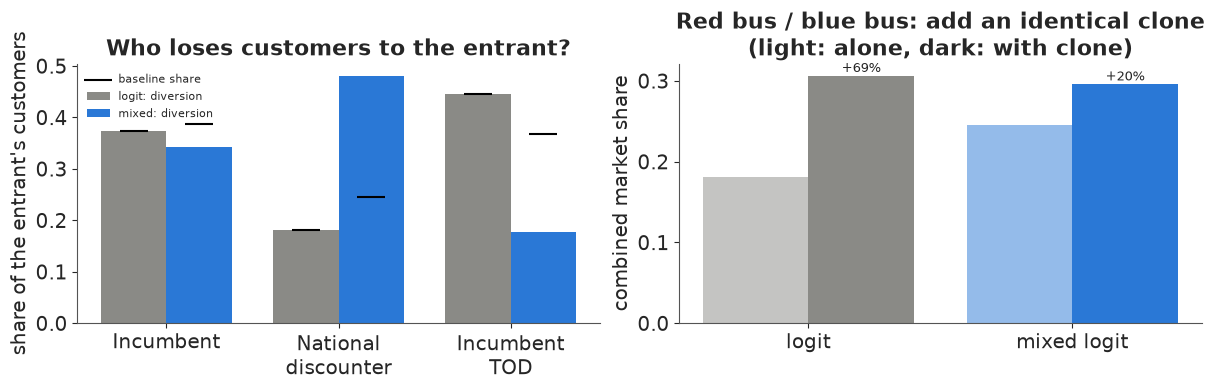

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
w = 0.38
for i, (m, col) in enumerate([("logit", GREY), ("mixed", BLUE)]):
    axes[0].bar(np.arange(3) + (i - 0.5) * w, subst.loc[m, [f"from {c}" for c in competitors.index]],
                width=w, color=col, label=f"{m}: diversion")
    axes[0].scatter(np.arange(3) + (i - 0.5) * w, base[m].mean(axis=0), marker="_", s=400, color="k",
                    zorder=3, label="baseline share" if i == 0 else None)
axes[0].set_xticks(range(3), ["Incumbent", "National\ndiscounter", "Incumbent\nTOD"])
axes[0].set(ylabel="share of the entrant's customers", title="Who loses customers to the entrant?")
axes[0].legend(fontsize=8)
for i, (m, col) in enumerate([("logit", GREY), ("mixed", BLUE)]):
    axes[1].bar(i - 0.2, subst.loc[m, "discounter alone"], width=0.4, color=col, alpha=0.5)
    axes[1].bar(i + 0.2, subst.loc[m, "discounter + clone"], width=0.4, color=col)
    axes[1].text(i + 0.2, subst.loc[m, "discounter + clone"] + 0.005,
                 f"+{subst.loc[m, 'discounter + clone'] / subst.loc[m, 'discounter alone'] - 1:.0%}",
                 ha="center", fontsize=9)
axes[1].set_xticks([0, 1], ["logit", "mixed logit"])
axes[1].set(ylabel="combined market share", title="Red bus / blue bus: add an identical clone\n(light: alone, dark: with clone)");

Under the logit, diversion ratios are **exactly** the baseline shares (IIA): the entrant, a
non-local fixed-price supplier, is assumed to steal most from the local incumbent TOD plan
simply because it is the biggest. The mixed logit disagrees: the entrant takes a much larger
share of its customers from the **national discounter**, the other non-local fixed-price offer,
because the people who already choose non-local fixed contracts are the ones who do not care
much about "local" and dislike variable rates.

The clone test shows the same thing more starkly. A perfect copy of the discounter should add
almost nothing - its customers were already served. The logit has the pair's share jump by
roughly 70%; the mixed logit by about 20%. The mixed logit reduces the red-bus problem but does
not remove it: conditional on $\beta_i$ each person still has independent Gumbel errors for
the two identical offers. Removing it entirely needs correlated errors between similar
alternatives (nested logit, or an error component in the mixed logit - see "Try it yourself").

## 8.3 · The pricing decision

The entrant's margin is its price minus a wholesale cost of **6 c/kWh** (an assumption for
illustration). Expected profit per kWh of the whole market is share $\times$ (price - 6). We
scan price and contract length. Prices outside 7-9 c/kWh are extrapolation beyond the survey
and are shaded.

expected-margin-maximising price by model and contract length:
                     best price  E[margin] c/100kWh
model contract (yr)                                
logit 0                    7.75               11.75
mixed 0                    7.25               18.52
logit 1                    7.75               10.62
mixed 1                    7.00               15.71
logit 5                    7.75                7.03
mixed 5                    6.75                9.37


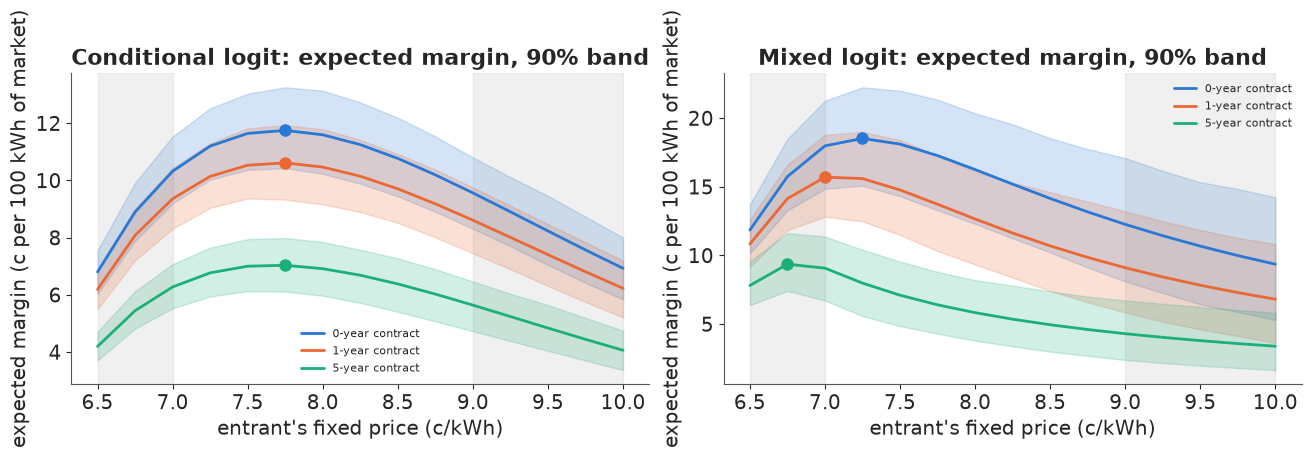

In [24]:
COST = 6.0
prices = np.arange(6.5, 10.01, 0.25)
profit = {}
for cl in [0, 1, 5]:
    for m in ["logit", "mixed"]:
        sh = np.stack([shares(np.vstack([C, [p, cl, 0, 0, 0, 0]]), m)[:, 3] for p in prices])
        profit[(m, cl)] = sh * (prices[:, None] - COST)                  # (price, draw)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, m in zip(axes, ["logit", "mixed"]):
    for cl, col in zip([0, 1, 5], [BLUE, ORANGE, AQUA]):
        pr = 100 * profit[(m, cl)]
        lo, med, hi = np.quantile(pr, [0.05, 0.5, 0.95], axis=1)
        ax.fill_between(prices, lo, hi, color=col, alpha=0.2)
        ax.plot(prices, pr.mean(axis=1), color=col, lw=2, label=f"{cl}-year contract")
        ax.plot(prices[pr.mean(axis=1).argmax()], pr.mean(axis=1).max(), "o", color=col, ms=8)
    for x0, x1 in [(6.5, 7), (9, 10)]:
        ax.axvspan(x0, x1, color=GREY, alpha=0.12)
    ax.set(xlabel="entrant's fixed price (c/kWh)", ylabel="expected margin (c per 100 kWh of market)",
           title=f"{'Conditional logit' if m == 'logit' else 'Mixed logit'}: expected margin, 90% band")
    ax.legend(fontsize=8)

best = {}
for (m, cl), pr in profit.items():
    i = pr.mean(axis=1).argmax()
    best[(m, cl)] = (prices[i], pr.mean(axis=1)[i])
print("expected-margin-maximising price by model and contract length:")
print(pd.DataFrame([{"model": m, "contract (yr)": cl, "best price": p, "E[margin] c/100kWh": 100 * v}
                    for (m, cl), (p, v) in best.items()]).set_index(["model", "contract (yr)"]).round(2))

The two models give different advice. The **logit** puts the best price at 7.75 c/kWh for every
contract length; the **mixed logit** at 7.25 without a contract (7.0 and 6.75 with 1- and 5-year
contracts), and it expects a higher margin at its optimum. Its bands are also much wider: taste
heterogeneity is uncertain, and it matters for shares. One reading of the lower price: with
heterogeneous tastes the entrant's natural customers are the not-local-minded people currently
with the discounter, who are already choosing on price, so it pays to compete on price for them
rather than charge a premium to everyone. Both models agree that **no contract** is best: every year of
lock-in costs the entrant customers.

How much would the entrant lose by following the logit? Evaluate the logit's recommendation
under the (better-supported) mixed logit, draw by draw.

In [25]:
p_logit, _ = best[("logit", 0)]
p_mixed, _ = best[("mixed", 0)]
pm_ = profit[("mixed", 0)]
gain = pm_[np.argmin(np.abs(prices - p_mixed))] - pm_[np.argmin(np.abs(prices - p_logit))]
print(f"mixed-logit optimum {p_mixed:.2f}c vs logit optimum {p_logit:.2f}c (no contract): "
      f"margin gain {100 * gain.mean():.2f} c/100kWh, 90% interval {q(100 * gain)[[0, 2]]}, "
      f"P(gain > 0) = {np.mean(gain > 0):.2f}")
print(f"relative to the logit's price: {gain.mean() / pm_[np.argmin(np.abs(prices - p_logit))].mean():+.0%}")

mixed-logit optimum 7.25c vs logit optimum 7.75c (no contract): margin gain 1.25 c/100kWh, 90% interval [-0.1   2.58], P(gain > 0) = 0.94
relative to the logit's price: +7%


Under the mixed logit, pricing at 7.25 instead of 7.75 raises the expected margin by about 7%,
with probability about 0.9 of being an improvement. The margin curve is flat near its peak, so
this is a modest gain, not a dramatic one; what changes more is the story of *whom* the entrant
competes with, which matters for how the discounter might respond.

**Caveats a pricing team should hear.** Stated preferences are hypothetical: people may
overstate their dislike of variable rates or their love of local firms (hypothetical bias).
The survey has no "no switch" option, so these are shares among switchers, not of all
households. The market is invented, the cost is assumed, and competitors will react. The
model's job is to make the trade-offs explicit and carry the uncertainty through, not to
replace these judgements.

## Summary

* **The logit** is a softmax over alternatives of a linear utility; in PyMC it is a
  `(task, alt, attr)` array and `pm.Categorical(logit_p=...)`. Priors must be checked on the
  choice scale: "vague" coefficients mean deterministic choices.
* **IIA** is a property of one person with fixed tastes. A person-level predictive check on the
  panel (67 people never chose a variable-rate contract; the logit expects one or two) shows
  that the population is not one person.
* **The mixed logit** (non-centred person effects, LKJ covariance) reproduces the person-level
  pattern and reveals correlated tastes. A **normal price coefficient** fits and samples fine
  but makes one in nine people like higher prices and gives WTP a distribution with no mean; a
  **lognormal** price coefficient fixes this; LOO leans its way only slightly (about 8 +- 5.5
  nats leaving out people).
* **WTP**: the median person values a local supplier at roughly 3 c/kWh, but the middle 80% of
  people range from about 0 to 20 c/kWh; means are tail-driven; individual WTPs from 12
  answers are very uncertain.
* **LOO for panels**: leave out the unit you want to predict. Leaving out people needs the
  integrated likelihood, and a naive simulated integral was off by about 100 nats; importance
  sampling from each person's posterior fixed it.
* **Decision**: the mixed logit's substitution patterns (the entrant takes from the similar
  discounter, not in proportion to shares) change the recommended price from 7.75 to 7.25
  c/kWh, with no contract, for about 7% more expected margin.

## Try it yourself

1. **WTP space.** Reparameterise the mixed logit directly in willingness to pay (Train & Weeks
   2005): $U = \lambda_i(-\text{price} + w_i^\top x)$ with $\lambda_i$ lognormal and $w_i$
   normal. Put priors on WTP directly. Does the population *mean* WTP for "local" become less
   tail-driven, and does person-level LOO change?
2. **An error component for the clone.** Add a normal error term, drawn afresh in every choice
   task, shared by the "non-local fixed-price" alternatives of that task (an error component
   that mimics a nest), and repeat the red-bus test of 8.2.
   How much of the clone's extra share disappears, and does the entrant's diversion change?
3. **A mass point of refusers.** Section 4.3's check showed slightly too few people who never
   choose variable rates. Add a latent class "never considers TOD/seasonal" (a two-component
   mixture per person, marginalised with `pt.logsumexp` over the person's 12 answers). What
   share of people are in it, and does the pricing of a TOD offer change?